<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day08_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 8 Lab: Linear Regression
## Scott Spurlock
### 2/26/26


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=18O_DAbFP6JtDQNAPjmHUSavyytnGei01')
df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data cleaning

In [3]:
df = df.drop(['Unnamed: 0'], axis=1)

In [4]:
# a mask tells which rows to keep
mask = (df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)
df = df[mask]

## Ordinal encode
cut: quality of the cut (Fair, Good, Very Good, Premium, Ideal)
color: diamond color, from J (worst) to D (best)
clarity: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))


In [5]:
# cut
ord_map = {
    'Fair':0,
    'Good':1,
    'Very Good': 2,
    'Premium': 3,
    'Ideal': 4
}
df['cut'] = df['cut'].map(ord_map)

# color
ord_map = {
    'J': 0,
    'I': 1,
    'H': 2,
    'G': 3,
    'F': 4,
    'E': 5,
    'D': 6
}
df['color'] = df['color'].map(ord_map)

# clarity
ord_map = {
    'I1': 0,
    'SI2': 1,
    'SI1': 2,
    'VS2': 3,
    'VS1': 4,
    'VVS2': 5,
    'VVS1': 6,
    'IF': 7
}
df['clarity'] = df['clarity'].map(ord_map)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  int64  
 2   color    53920 non-null  int64  
 3   clarity  53920 non-null  int64  
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


In [7]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


## Divide your data in y, the price, and X, everything else.
Use double square brackets to keep things 2D


In [8]:
y = df[['price']]
X = df.drop('price', axis=1) # X is everything but price

Divide your data into training and test sets using train_test_split, so that you have Xtrain, Xtest, ytrain, ytest.

In [9]:
# Split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X,
                                                y,
                                                test_size=0.3,
                                                random_state=0)


In [10]:
Xtrain.shape

(37744, 9)

Normalize the training data. Then normalize the testing data using the same min/max as you did the training data (see example in slides). No need to normalize the output variable, y, the price.

In [11]:
Xmin = Xtrain.min(axis=0)
Xmax = Xtrain.max(axis=0)
Xtrain = (Xtrain - Xmin) / (Xmax - Xmin)
Xtest = (Xtest - Xmin) / (Xmax - Xmin)


Train a simple linear regression model that just uses one feature, carat, to predict the y, the output, price. E.g., try Xtrain[['carat']].

In [12]:
Xtrain.shape

(37744, 9)

In [13]:
ytrain.shape

(37744, 1)

In [14]:
model = LinearRegression(fit_intercept=True)
model.fit(Xtrain[['carat']], ytrain)
ypred = model.predict(Xtest[['carat']])

# see model parameters
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)


Model slope:     [37243.22177661]
Model intercept: [-699.99290521]


Predict the test set, and make the following graph:

In [15]:
ypred = model.predict(Xtest[['carat']])

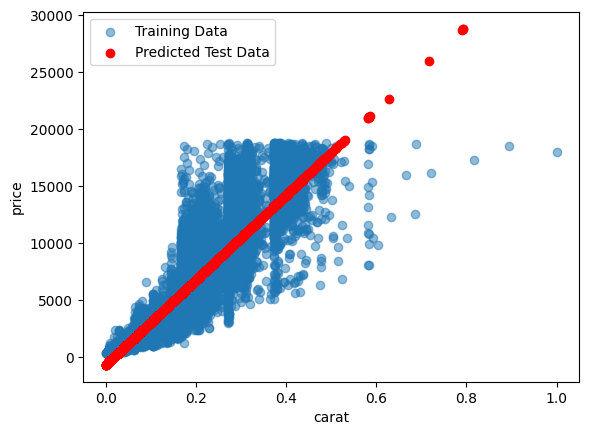

In [16]:
plt.scatter(Xtrain['carat'], ytrain, alpha=0.5, label='Training Data')
plt.scatter(Xtest['carat'], ypred, c='red', label='Predicted Test Data')
plt.xlabel('carat')
plt.ylabel('price')
plt.legend()





---


# From here down is optional


---


## Polynomial features

In [17]:
for d in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())

    model.fit(Xtrain[['carat']], ytrain)

    ypred = model.predict(Xtest[['carat']])

    mae = mean_absolute_error(ytest, ypred)
    mse = mean_squared_error(ytest, ypred)

    print(f'Polyn degree {d} ... MAE: {mae:.4f}, MSE: {mse:.4f}')


Polyn degree 1 ... MAE: 1015.8945, MSE: 2441522.2010
Polyn degree 2 ... MAE: 961.7823, MSE: 2414371.2908
Polyn degree 3 ... MAE: 850.7582, MSE: 2154371.8087
Polyn degree 4 ... MAE: 838.7487, MSE: 2105274.6056
Polyn degree 5 ... MAE: 833.0338, MSE: 2103867.0310
Polyn degree 6 ... MAE: 828.0548, MSE: 2096950.5062
Polyn degree 7 ... MAE: 827.5546, MSE: 2096019.3990
Polyn degree 8 ... MAE: 828.2830, MSE: 2098029.3592
Polyn degree 9 ... MAE: 828.7129, MSE: 2100862.7593
Polyn degree 10 ... MAE: 829.4036, MSE: 2098780.8058


Pick the polynomial degree with the lowest error

In [18]:
best_degree = 6
model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
model.fit(Xtrain[['carat']], ytrain)
ypred = model.predict(Xtest[['carat']])
mae = mean_absolute_error(ytest, ypred)
mae

828.0548289032903

Using the best polynomial degree you can find, show an updated plot

Does this model necessarily seem best?

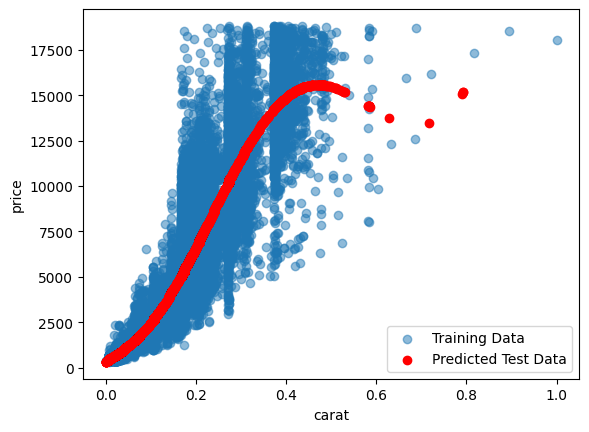

In [19]:
plt.scatter(Xtrain['carat'], ytrain, alpha=0.5, label='Training Data')
plt.scatter(Xtest['carat'], ypred, c='red', label='Predicted Test Data')
plt.xlabel('carat')
plt.ylabel('price')
plt.legend()


## Finally let's experiment with using all the features (not just carat)

In [20]:
for d in [1, 2, 3, 4, 5]:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())

    model.fit(Xtrain, ytrain)

    ypred = model.predict(Xtest)

    mae = mean_absolute_error(ytest, ypred)
    mse = mean_squared_error(ytest, ypred)

    print(f'Polyn degree {d} ... MAE: {mae:.4f}, MSE: {mse:.4f}')


Polyn degree 1 ... MAE: 812.7523, MSE: 2014505.1196
Polyn degree 2 ... MAE: 748.7202, MSE: 1019259388.7858
Polyn degree 3 ... MAE: 52788.9545, MSE: 34928074745067.4766
Polyn degree 4 ... MAE: 6030496.3178, MSE: 543758074656249024.0000
Polyn degree 5 ... MAE: 1165786717.2251, MSE: 21406150987797678260224.0000


In [21]:
best_degree = 2
model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)
mae = mean_absolute_error(ytest, ypred)
mae

748.720161929421

We can't show all the features in a 2D scatter plot, so let's just show carat again, even though this model using all the features

(0.0, 1.0)

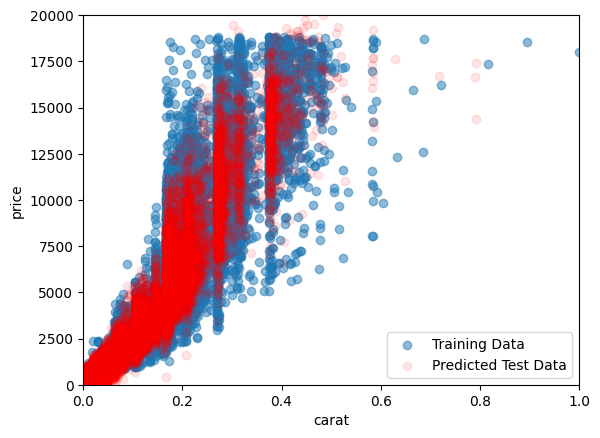

In [22]:
plt.scatter(Xtrain['carat'], ytrain, alpha=0.5, label='Training Data')
plt.scatter(Xtest['carat'], ypred, c='red', alpha=0.1, label='Predicted Test Data')
plt.xlabel('carat')
plt.ylabel('price')
plt.legend()
plt.ylim(0, 20000)
plt.xlim(0, 1)